
#  EDA — ShanghaiTech Anomaly Detection

Este cuaderno realiza un **análisis exploratorio** sobre la versión procesada del dataset **ShanghaiTech** descargado desde Kaggle.
El dataset contiene imágenes ya extraídas de los videos originales:

- `frames/` → imágenes RGB por video  
- `optical_flow/` → imágenes de flujo óptico entre frames consecutivos

---

##  Objetivos del EDA
1. Verificar la estructura y consistencia de las carpetas.  
2. Contar número de frames y optical flow por video.  
3. Detectar posibles videos incompletos.  
4. Graficar distribuciones y ejemplos visuales.



## 1️ Configuración de rutas


In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# --- Configuración correcta ---
PROJECT_ROOT = Path("/teamspace/studios/this_studio/anomaly_detection")
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "dataset" / "mp"
META_DIR = PROJECT_ROOT / "data" / "processed" / "metadata"
META_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("Archivos de ejemplo:", list(DATA_ROOT.glob('*'))[:3])

PROJECT_ROOT: /teamspace/studios/this_studio/anomaly_detection
DATA_ROOT: /teamspace/studios/this_studio/anomaly_detection/data/raw/dataset/mp
Archivos de ejemplo: [PosixPath('/teamspace/studios/this_studio/anomaly_detection/data/raw/dataset/mp/01_072'), PosixPath('/teamspace/studios/this_studio/anomaly_detection/data/raw/dataset/mp/01_040'), PosixPath('/teamspace/studios/this_studio/anomaly_detection/data/raw/dataset/mp/09_001')]



## Indexación de videos y conteo de imágenes
Cada carpeta de video contiene dos subcarpetas:
- `frames/`
- `optical_flow/`

Se recorre el dataset para contar cuántas imágenes hay de cada tipo.


In [7]:

def scan_frames(root: Path) -> pd.DataFrame:
    rows = []
    for video_dir in root.iterdir():
        if not video_dir.is_dir():
            continue
        n_frames = len(list(video_dir.glob("frames/*.jpg")))
        n_flow   = len(list(video_dir.glob("optical_flow/*.jpg")))
        rows.append({
            "video_id": video_dir.name,
            "frames": n_frames,
            "optical_flow": n_flow
        })
    return pd.DataFrame(rows)

df_meta = scan_frames(DATA_ROOT)
meta_path = META_DIR / 'frames_metadata.csv'
df_meta.to_csv(meta_path, index=False)
print(f"✅ Metadata guardada en: {meta_path}")
df_meta.head()


✅ Metadata guardada en: /teamspace/studios/this_studio/anomaly_detection/data/processed/metadata/frames_metadata.csv


,video_id,frames,optical_flow
0,01_072,1051,1051
1,01_040,1166,1166
2,09_001,1406,1406
3,07_001,648,648
4,01_041,876,876



##  Validación básica
Buscamos videos sin frames o sin optical flow (incompletos).


In [8]:

print("Videos sin frames:")
display(df_meta[df_meta["frames"] == 0])

print("Videos sin optical flow:")
display(df_meta[df_meta["optical_flow"] == 0])


Videos sin frames:


,video_id,frames,optical_flow


Videos sin optical flow:


,video_id,frames,optical_flow



## Estadísticas descriptivas y distribuciones


Resumen estadístico:


,frames,optical_flow
count,330.000000,330.000000
mean,830.863636,830.863636
std,393.090200,393.090200
min,199.000000,199.000000
25%,648.250000,648.250000
50%,771.000000,771.000000
75%,957.250000,957.250000
max,4168.000000,4168.000000


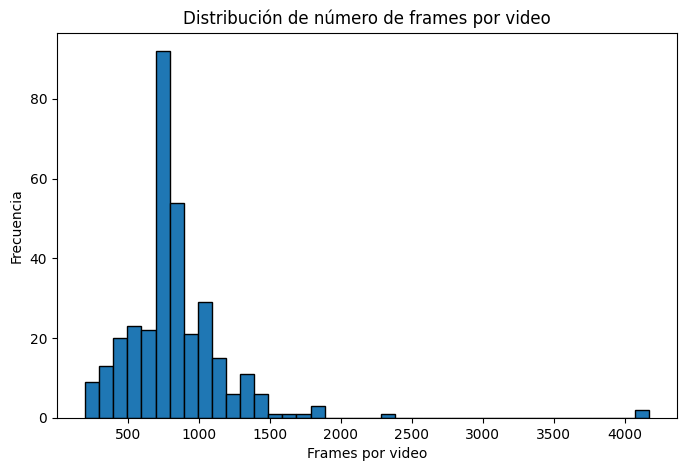

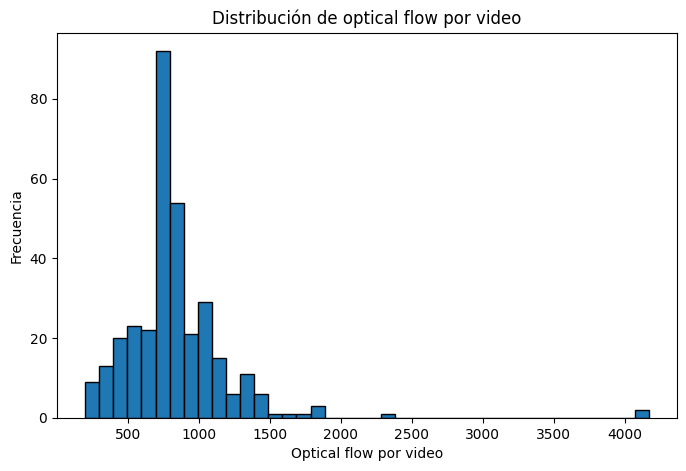

In [9]:

print("Resumen estadístico:")
display(df_meta.describe())

plt.figure(figsize=(8,5))
plt.hist(df_meta["frames"], bins=40, edgecolor="black")
plt.title("Distribución de número de frames por video")
plt.xlabel("Frames por video")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df_meta["optical_flow"], bins=40, edgecolor="black")
plt.title("Distribución de optical flow por video")
plt.xlabel("Optical flow por video")
plt.ylabel("Frecuencia")
plt.show()



## Visualización de ejemplos (Frame + Optical Flow)


Ejemplo de carpeta: /teamspace/studios/this_studio/anomaly_detection/data/raw/dataset/mp/01_072


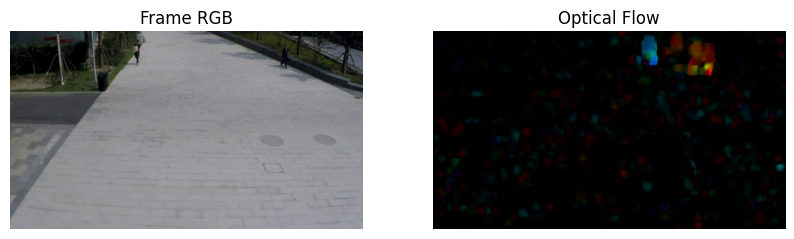

In [10]:

example_video = next(DATA_ROOT.iterdir())
print("Ejemplo de carpeta:", example_video)

example_frame = next((example_video / "frames").glob("*.jpg"))
example_flow  = next((example_video / "optical_flow").glob("*.jpg"))

f1 = cv2.cvtColor(cv2.imread(str(example_frame)), cv2.COLOR_BGR2RGB)
f2 = cv2.cvtColor(cv2.imread(str(example_flow)), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(f1); plt.title("Frame RGB"); plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(f2); plt.title("Optical Flow"); plt.axis("off")
plt.show()



## Resumen final


In [12]:

total_videos = len(df_meta)
total_frames = df_meta["frames"].sum()
total_flow = df_meta["optical_flow"].sum()

print(f"Total videos: {total_videos:,}")
print(f"Total frames RGB: {total_frames:,}")
print(f"Total optical flow: {total_flow:,}")

incomplete = df_meta[(df_meta["frames"] == 0) | (df_meta["optical_flow"] == 0)]
print(f"Videos incompletos: {len(incomplete)}")


Total videos: 330
Total frames RGB: 274,185
Total optical flow: 274,185
Videos incompletos: 0
